<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026
</div>

# Atmosphere Analysis 4 — Differential Flux with MCEq

**Description:** Uses the MCEq cascade-equation solver through the tpeanuts
`external.mceq` API to produce the height-differential atmospheric neutrino source flux
$\Phi(E,h;\theta) = \Phi(E;\theta) \times f(h|E,\theta)$ used as the upper boundary
condition for atmosphere-neutrino propagation.

**Physics:** MCEq cascade transport equation · slant-depth-to-height transformation · height-differential source flux $\Phi(E,h)$


| # | Section |
|---|---------|
| [0](#0.-Theory-Background) | **Theory Background**: 0.1 MCEq cascade equation, 0.2 physical model configuration, 0.3 slant-depth-to-height, 0.4 differential flux $\Phi(E,h;\theta)$, 0.5 PDF extraction |
| [1](#1.-Libraries) | **Libraries**: imports and configuration |
| [2](#2.-MCEq-Configuration) | **MCEq Configuration**: 2.1 available models, 2.2 model \& grid setup |
| [3](#3.-Single-Direction-Differential-Flux) | **Single-Direction Differential Flux**: 3.1 integrated $\Phi(E;\theta)$, 3.2 cascade solution $\Phi(E,X;\theta)$, 3.3 height PDF $f(h|E)$, 3.4 $\Phi(E,h)$ heatmap |
| [4](#4.-Angular-Dependence) | **Angular Dependence**: 4.1 multi-angle grid, 4.2 angular profiles |
| [5](#5.-Production-Height-Statistics) | **Production Height Statistics**: 5.1 median height, 5.2 height PDF heatmap |
| [6](#6.-Particle-and-Flavour-Comparison) | **Particle Comparison**: 6.1 $\nu_e$ vs $\nu_\mu$ spectra, 6.2 $\nu/\bar\nu$ ratios |
| [7](#7.-Physical-Model-Comparison) | **Physical Model Comparison**: 7.1 interaction models, 7.2 density models |
| [8](#8.-Flux-Normalization-Check) | **Flux Normalization**: 8.1 integrate $f(h|E)\,\mathrm{d}h$ |
| [9](#9.-Summary) | **Summary** |

## 0. Theory Background

---

### 0.1 MCEq and the Cascade Transport Equation

**MCEq** (Matrix Cascade Equations, Fedynitch et al. 2015) is a numerical solver for
the coupled cascade transport equations that govern the propagation of every particle
species through the atmosphere. Starting from a primary cosmic-ray flux injected at the
top of the atmosphere, MCEq integrates:

$$\frac{d\Phi_i}{dX} = -\frac{\Phi_i}{\lambda_i} + \sum_j \frac{c_{j\to i}\,\Phi_j}{\lambda_j} + \frac{\partial}{\partial E}\!\left(\frac{\Phi_i}{\rho(X)\,d_i}\right)$$

for every species $i$ (nucleons, pions, kaons, muons, neutrinos, ...) as a function
of **atmospheric slant depth** $X$ (g/cm$^2$), the column density of air traversed
along the shower axis at zenith angle $\theta$. The physical ingredients are:

- $\lambda_i$: interaction or decay length of species $i$
- $c_{j\to i}$: production yield of $i$ from $j$ (set by the hadronic **interaction model**)
- $\rho(X)$: atmospheric mass density at depth $X$ (set by the **density model**)
- $d_i$: continuous energy-loss coefficient (non-zero for muons only)

MCEq yields $\Phi_i(E, X; \theta)$ — the energy- and depth-resolved flux for every
species. Unlike Honda tables, the full depth profile is available directly,
so the height-differential flux is extracted analytically from the cascade solution.

**References:**
- A. Fedynitch, R. Engel, T. K. Gaisser, F. Riehn, T. Stanev,
  *Calculation of conventional and prompt lepton fluxes at very high energy*,
  EPJ Web Conf. **99**, 08001 (2015).
- T. K. Gaisser, R. Engel, E. Resconi,
  *Cosmic Rays and Particle Physics*, Cambridge University Press (2016).

---

### 0.2 Physical Model Configuration

Three independent physics choices fully determine the cascade solve:

| Class | Parameter | Role |
|---|---|---|
| `MCEqModelConfig` | `interaction_model` | Hadronic yields $c_{j\to i}$ — controls $\nu_e/\nu_\mu$ ratio and overall normalisation |
| `MCEqModelConfig` | `primary_model` | Primary CR boundary condition $\Phi_\text{CR}(E)$ at the top of atmosphere |
| `MCEqModelConfig` | `density_model` | Atmospheric density profile $\rho(X)$, site- and season-specific |
| `GridConfig` | `X_grid_gcm2` | Slant-depth grid on which the cascade ODE is integrated |
| `GridConfig` | `h_grid_km` | Output altitude grid for $f(h|E,\theta)$ and $\Phi(E,h;\theta)$ |
| `GridConfig` | `X_obs_gcm2` | Observation depth where $\Phi(E;\theta)$ is extracted (default 1030 g/cm$^2$) |
| `SmoothingConfig` | `method` | Smoothing applied before numerical differentiation of $\Phi(E,X)$ |

Available interaction models include `QGSJETII04`, `SIBYLL23D`, `EPOSLHC`;
available density models include `CORSIKA` (US Standard), `ICECUBE` (South Pole).

---

### 0.3 From Slant Depth to Production Height

MCEq solves on slant depth $X$ (g/cm$^2$). The altitude $h$ (km) is related to $X$
through the atmospheric density model:

$$X(h, \theta) = \frac{1}{\cos\theta} \int_h^\infty \rho(h^\prime)\,dh^\prime$$

The Jacobian of this change of variables is $|dX/dh| = \rho(h)/\cos\theta$.
Evaluating $X(h,\theta)$ on the output altitude grid $\{h_k\}$ and computing
$|dX/dh|$ numerically converts the depth-domain production source into the
height-domain source:

$$Q_\text{eff}(E, h; \theta) = \max\!\left(\frac{d\Phi}{dX}, 0\right)_{X(h,\theta)} \times \left|\frac{dX}{dh}\right|$$

---

### 0.4 Height-Differential Flux $\Phi(E, h;\, \theta)$

The **height-differential flux** is the quantity tpeanuts uses as the upper boundary
condition for atmospheric neutrino propagation:

$$\boxed{\Phi(E,\,h;\,\theta) \;=\; \Phi(E;\,\theta) \;\times\; f(h\,|\,E,\,\theta)}$$

where $\Phi(E;\theta) = \Phi(E, X_\text{obs}; \theta)$ is the energy-differential
flux extracted at the observation depth $X_\text{obs}$ (default 1030 g/cm$^2$, sea level),
and $f(h|E,\theta)$ is the production-height PDF normalised so that

$$\int_0^{h_{\rm top}} f(h\,|\,E,\,\theta)\,\mathrm{d}h \;=\; 1.$$

The units of $\Phi(E,h;\theta)$ are $(\mathrm{cm}^2\,\mathrm{s}\,\mathrm{sr}\,\mathrm{GeV}\,\mathrm{km})^{-1}$.

---

### 0.5 Production-Height PDF Extraction from the Cascade Solution

The PDF $f(h|E,\theta)$ is extracted from the depth-resolved MCEq flux in four steps:

1. **Smooth**: apply a smoothing spline (or Gaussian kernel) to $\Phi(E,X;\theta)$
   along the depth axis before differentiating, suppressing numerical noise.
2. **Differentiate**: compute $Q_\text{eff}(E,X;\theta) = \max(d\Phi/dX,\,0)$
   (clipped to non-negative values; negative values are unphysical production rates).
3. **Transform**: convert $Q_\text{eff}(E,X)$ to $Q_\text{eff}(E,h)$ using the Jacobian $|dX/dh|$.
4. **Normalise**: $f(h|E,\theta) = Q_\text{eff}(E,h;\theta)\,/\,\int Q_\text{eff}\,dh$,
   enforcing unit norm on the discrete grid.

This is the MCEq analogue of the quantile-based CDF reconstruction used for Honda tables
(atmosphere2 §0.5). Both approaches yield the same $\Phi(E,h;\theta)$ contract.

---

**References**
- A. Fedynitch, H. Dembinski, R. Engel, T. K. Gaisser, F. Riehn, T. Stanev,
  *A state-of-the-art calculation of atmospheric lepton fluxes*,
  PoS(ICRC2017) **301**, 1019 (2017).
- F. Riehn, R. Engel, A. Fedynitch, T. K. Gaisser, T. Stanev,
  *Hadronic interaction model Sibyll 2.3d and enhanced predictions*,
  Phys. Rev. D **102**, 063002 (2020).

## 1. Libraries

Imports and notebook configuration.

> **Import order note:** `tpeanuts.medium.atmosphere.density` imports `MCEqModelConfig`
> at module level, creating a circular dependency
> (`mceq.config` → `atmosphere.io` → `__init__` → `density` → `mceq.config`).
> Importing `atmosphere.io` **first** ensures `medium.atmosphere` is fully initialised
> before `mceq.config` is first touched, breaking the cycle.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

# Import medium.atmosphere first to avoid circular import with mceq.config
from tpeanuts.medium.atmosphere.io import OutputConfig
from tpeanuts.util.parallel import ParallelConfig

from tpeanuts.external.mceq.config import (
    MCEqModelConfig, GridConfig, SmoothingConfig,
    INTERACTION_MODELS, PRIMARY_MODELS, DENSITY_MODELS,
    DEFAULT_INTERACTION_MODEL, DEFAULT_PRIMARY_MODEL, DEFAULT_DENSITY_MODEL,
)
from tpeanuts.external.mceq.generator import (
    generate_flux_for_particle_angle,
    generate_flux_for_particles_angle_grid,
)

In [2]:
config     = load_notebook_config()
OUTPUT_DIR = config.output_dir('analysis', 'atmosphere', 'mceq_analysis')
SHOW_PLOTS = config.show_plots
print(f'Output directory : {OUTPUT_DIR}')
print(f'Device           : {config.device}')

Output directory : v:\output\analysis\atmosphere\mceq_analysis
Device           : cpu


## 2. MCEq Configuration

MCEq does not read pre-computed data files: it solves the cascade equation from
first principles each time. Configuration is entirely through three dataclasses:
`MCEqModelConfig` (physics models), `GridConfig` (numerical grids), and
`SmoothingConfig` (derivative extraction).

### 2.1 Available Models

The constants `INTERACTION_MODELS`, `PRIMARY_MODELS`, and `DENSITY_MODELS`
exported from `tpeanuts.external.mceq.config` enumerate every supported option.

In [3]:
print(f'Interaction models ({len(INTERACTION_MODELS)}):')
for m in INTERACTION_MODELS:
    tag = '  <-- default' if m == DEFAULT_INTERACTION_MODEL else ''
    print(f'  {m}{tag}')
print()
print(f'Primary models ({len(PRIMARY_MODELS)}):')
for k in PRIMARY_MODELS:
    tag = '  <-- default' if k == DEFAULT_PRIMARY_MODEL else ''
    print(f'  {k!r}{tag}')
print()
print(f'Density models ({len(DENSITY_MODELS)}):')
for k, v in DENSITY_MODELS.items():
    tag = '  <-- default' if k == DEFAULT_DENSITY_MODEL else ''
    print(f'  {k:15s} -> {v}{tag}')

Interaction models (12):
  DPMJETIII193
  EPOSLHC
  EPOSLHCR
  QGSJETII04
  QGSJETIII
  SIBYLL21
  SIBYLL23D  <-- default
  SIBYLL23E
  SIBYLL23ESTARBAR
  SIBYLL23ESTARMIXED
  SIBYLL23ESTARRHO
  SIBYLL23ESTARSTRANGE

Primary models (7):
  'HillasGaisser H3a'  <-- default
  'HillasGaisser H4a'
  'GST 3-gen'
  'GST 4-gen'
  'PolyGonato'
  'GlobalSplineFitBeta'
  'GaisserHonda'

Density models (4):
  CORSIKA         -> ('CORSIKA', ('USStd', None))  <-- default
  NASA            -> ('MSIS00', ('SouthPole', 'January'))
  ICECUBE         -> ('MSIS00_IC', ('SouthPole', 'January'))
  ISOTHERMAL      -> ('Isothermal', ('', ''))


### 2.2 Model and Grid Configuration

`MCEqModelConfig` selects the physics models. `GridConfig` sets the numerical
grids: the depth grid on which MCEq solves the ODE ($X$), the altitude output grid
($h$), and the observation depth $X_\text{obs}$ at which $\Phi(E;\theta)$ is extracted.
`SmoothingConfig` controls the smoothing applied before computing $d\Phi/dX$.

| Parameter | Meaning | Example values |
|-----------|---------|----------------|
| `interaction_model` | Hadronic production model | `"QGSJETII04"`, `"SIBYLL23D"`, `"EPOSLHC"` |
| `primary_model` | Primary CR flux at TOA | `"HillasGaisser H3a"`, `"PolyGonato"` |
| `density_model` | Atmospheric density profile | `"CORSIKA"` (US Std), `"ICECUBE"` (S. Pole) |
| `X_obs_gcm2` | Observation depth (g/cm$^2$) | `1030.0` (sea level) |
| `method` | Smoothing before $d\Phi/dX$ | `"spline"`, `"gaussian"`, `"none"` |

**Expected results:**
- All three config objects validate without errors.

In [4]:
# --- physics models ---
INTERACTION_MODEL = "QGSJETII04"
PRIMARY_MODEL     = "HillasGaisser H3a"
DENSITY_MODEL     = "CORSIKA"

model_config = MCEqModelConfig(
    interaction_model = INTERACTION_MODEL,
    primary_model     = PRIMARY_MODEL,
    density_model     = DENSITY_MODEL,
    info              = False,
)
model_config.validate()

# --- numerical grids ---
X_OBS_GCM2  = 1030.0
X_GRID_GCM2 = torch.linspace(1.0, X_OBS_GCM2, 101, dtype=torch.float64)
H_GRID_KM   = torch.linspace(0.0, 120.0, 501, dtype=torch.float64)

grid_config = GridConfig(
    theta_grid_deg = torch.tensor([0.0]),   # placeholder; overridden per angle at solve time
    X_grid_gcm2    = X_GRID_GCM2,
    h_grid_km      = H_GRID_KM,
    X_obs_gcm2     = X_OBS_GCM2,
)
grid_config.validate()

# --- smoothing ---
smoothing_config = SmoothingConfig(
    method         = "spline",
    smoothing      = 1.0e-4,
    gaussian_sigma = 2.0,
    positive_only  = True,
)
smoothing_config.validate()

print(f"Interaction model : {INTERACTION_MODEL}")
print(f"Primary model     : {PRIMARY_MODEL}")
print(f"Density model     : {DENSITY_MODEL}")
print(f"X grid            : {len(X_GRID_GCM2)} pts, {float(X_GRID_GCM2[0]):.1f} -- {float(X_GRID_GCM2[-1]):.0f} g/cm2")
print(f"h grid            : {len(H_GRID_KM)} pts, {float(H_GRID_KM[0]):.0f} -- {float(H_GRID_KM[-1]):.0f} km")
print(f"X_obs             : {X_OBS_GCM2} g/cm2")
print(f"Smoothing         : method=spline, strength=1e-4, positive_only=True")

Interaction model : QGSJETII04
Primary model     : HillasGaisser H3a
Density model     : CORSIKA
X grid            : 101 pts, 1.0 -- 1030 g/cm2
h grid            : 501 pts, 0 -- 120 km
X_obs             : 1030.0 g/cm2
Smoothing         : method=spline, strength=1e-4, positive_only=True


## 3. Single-Direction Differential Flux

`generate_flux_for_particle_angle()` runs the full MCEq pipeline for one particle
at one zenith angle. It:
1. Solves the cascade ODE on the $X$ grid to obtain $\Phi(E, X; \theta)$.
2. Extracts $\Phi(E;\theta) = \Phi(E, X_\text{obs}; \theta)$ at the observation depth.
3. Smooths and differentiates to get $Q_\text{eff}(E,X;\theta) = \max(d\Phi/dX, 0)$.
4. Converts to the altitude domain via the $|dX/dh|$ Jacobian and normalises to $f(h|E,\theta)$.
5. Returns the product $\Phi(E,h) = \Phi(E;\theta) \times f(h|E,\theta)$.

In [5]:
THETA_DEG = 30.0     # zenith angle in degrees (0 = straight down, 90 = horizontal)
PARTICLE  = "numu"

print(f'Running MCEq for {PARTICLE}, theta = {THETA_DEG} deg ...')
print(f'Model: {INTERACTION_MODEL} / {PRIMARY_MODEL} / {DENSITY_MODEL}')

result = generate_flux_for_particle_angle(
    PARTICLE,
    theta_deg        = THETA_DEG,
    model_config     = model_config,
    grid_config      = grid_config,
    smoothing_config = smoothing_config,
    save             = False,
    device           = 'cpu',
    dtype            = torch.float64,
    debug            = True,
)

E_GeV    = result['E_grid_GeV'].cpu().numpy()        # (nE,)  energy grid [GeV]
X_gcm2   = result['X_grid_gcm2'].cpu().numpy()       # (nX,)  slant depth [g/cm2]
h_km     = result['h_grid_km'].cpu().numpy()          # (nh,)  altitude [km]
phi_E    = result['phi_E_obs'].cpu().numpy()          # (nE,)  height-integrated flux
f_Eh     = result['f_Eh'].cpu().numpy()              # (nE, nh)  height PDF [km-1]
phi_Eh   = result['phi_Eh'].cpu().numpy()            # (nE, nh)  Phi(E,h) [cm-2 s-1 sr-1 GeV-1 km-1]
flux_XE  = result['flux_XE'].cpu().numpy()           # (nX, nE)  raw cascade solution
flux_sXE = result['flux_smooth_XE'].cpu().numpy()    # (nX, nE)  smoothed

print(f'Energy grid : {E_GeV.size} points, {E_GeV[0]:.3f} -- {E_GeV[-1]:.0f} GeV')
print(f'Depth  grid : {X_gcm2.size} points, {X_gcm2[0]:.1f} -- {X_gcm2[-1]:.0f} g/cm2')
print(f'Height grid : {h_km.size} points, {h_km[0]:.0f} -- {h_km[-1]:.0f} km')
print(f'phi_E shape : {phi_E.shape}')
print(f'f_Eh  shape : {f_Eh.shape}')
print(f'phi_Eh shape: {phi_Eh.shape}')

Running MCEq for numu, theta = 30.0 deg ...
Model: QGSJETII04 / HillasGaisser H3a / CORSIKA
Generating numu | alpha=None deg | theta=30.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
Energy grid : 121 points, 0.089 -- 89125093813 GeV
Depth  grid : 101 points, 1.0 -- 1030 g/cm2
Height grid : 501 points, 0 -- 120 km
phi_E shape : (121,)
f_Eh  shape : (121, 501)
phi_Eh shape: (121, 501)


### 3.1 Height-Integrated Energy Spectrum $\Phi(E; \theta)$

$\Phi(E;\theta)$ is the total (height-integrated) flux at the observation depth
$X_\text{obs} = 1030\,\text{g/cm}^2$ for a fixed zenith angle $\theta$.
This is the MCEq equivalent of the quantity published directly in Honda tables.

**Expected results:**
- A steeply falling spectrum from $\sim 10$ (cm$^2$ s sr GeV)$^{-1}$ at 0.1 GeV
  to $\sim 10^{-9}$ at 100 GeV. The $E^2$-weighted version reveals the spectral shape.

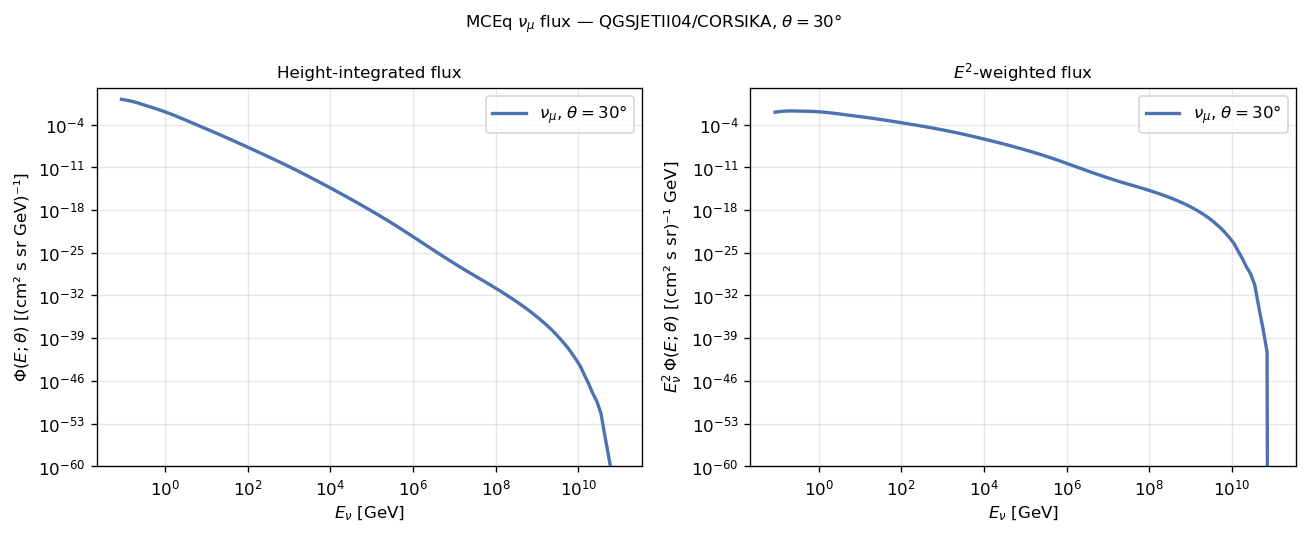

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig31_phi_E.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.loglog(E_GeV, phi_E, color='#4c72b0', lw=2,
          label=rf'$\nu_\mu$, $\theta={THETA_DEG:.0f}°$')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$\Phi(E; \theta)$ [(cm² s sr GeV)⁻¹]')
ax.set_title('Height-integrated flux', fontsize=10)
ax.set_ylim(1e-60,1e2)
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.loglog(E_GeV, phi_E * E_GeV**2, color='#4c72b0', lw=2,
          label=rf'$\nu_\mu$, $\theta={THETA_DEG:.0f}°$')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$E_\nu^2\,\Phi(E; \theta)$ [(cm² s sr)⁻¹ GeV]')
ax.set_title(r'$E^2$-weighted flux', fontsize=10)
ax.set_ylim(1e-60,1e2)
ax.legend()
ax.grid(True, which='both', alpha=0.3)

fig.suptitle(
    rf'MCEq $\nu_\mu$ flux — {INTERACTION_MODEL}/{DENSITY_MODEL}, $\theta={THETA_DEG:.0f}°$',
    fontsize=10,
)
fig.tight_layout()
save_and_show('atm4_fig31_phi_E.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.2 Cascade Solution $\Phi(E, X;\, \theta)$

The raw MCEq cascade solution $\Phi(E,X;\theta)$ (dashed) and its smoothed version
(solid) as a function of slant depth $X$ at several energies. This intermediate result
is unique to MCEq — Honda tables provide only the endpoint $\Phi(E,X_\text{obs};\theta)$.

The flux rises steeply from the top of atmosphere ($X \approx 0$) as pions and kaons are
produced and decay, then saturates near $X_\text{obs} = 1030\,\text{g/cm}^2$.
The smoothed profile is what gets differentiated to extract $Q_\text{eff}(E,X;\theta)$.

**Expected results:**
- A steeply rising profile that flattens near $X_\text{obs}$, with the
  smoothed curve closely tracking the raw one but without numerical noise.

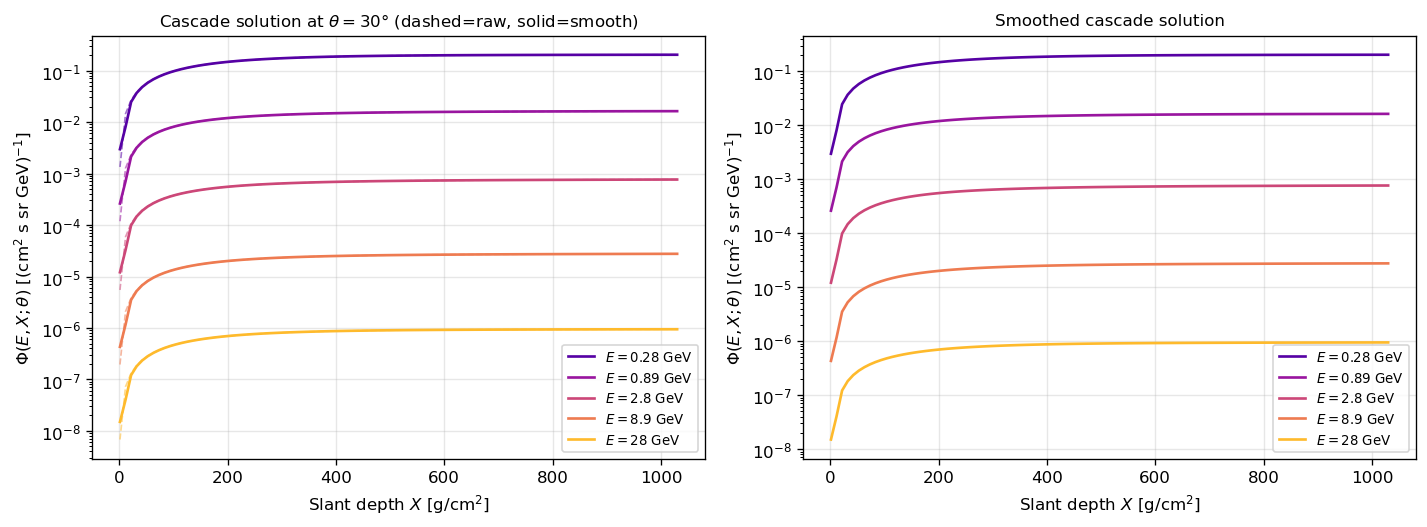

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig32_phi_EX.png


In [7]:
E_show   = [0.3, 1.0, 3.0, 10.0, 30.0]
colors_e = plt.cm.plasma(np.linspace(0.15, 0.85, len(E_show)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for e_tgt, col in zip(E_show, colors_e):
    ie = np.argmin(np.abs(E_GeV - e_tgt))
    label = rf'$E={E_GeV[ie]:.2g}$ GeV'
    axes[0].semilogy(X_gcm2, flux_XE[:, ie],  color=col, lw=1.0, ls='--', alpha=0.55)
    axes[0].semilogy(X_gcm2, flux_sXE[:, ie], color=col, lw=1.6, label=label)
    axes[1].semilogy(X_gcm2, flux_sXE[:, ie], color=col, lw=1.6, label=label)

axes[0].set_xlabel(r'Slant depth $X$ [g/cm$^2$]')
axes[0].set_ylabel(r'$\Phi(E,X;\theta)$ [(cm$^2$ s sr GeV)$^{-1}$]')
axes[0].set_title(rf'Cascade solution at $\theta={THETA_DEG:.0f}°$ (dashed=raw, solid=smooth)', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel(r'Slant depth $X$ [g/cm$^2$]')
axes[1].set_ylabel(r'$\Phi(E,X;\theta)$ [(cm$^2$ s sr GeV)$^{-1}$]')
axes[1].set_title('Smoothed cascade solution', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
save_and_show('atm4_fig32_phi_EX.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.3 Production Height PDF $f(h|E, \theta)$

The production-height PDF $f(h|E,\theta)$ encodes where in the atmosphere the
neutrino was produced. In MCEq it is computed from the depth-resolved cascade
solution via smoothing, differentiation, Jacobian transformation, and normalisation.

- At **low energy** ($E_\nu \lesssim 0.3$ GeV) pion decays dominate: production is
  spread over a wide height range, peaking around 15–25 km.
- At **high energy** ($E_\nu \gtrsim 3$ GeV) muon decays dominate and the distribution
  shifts to lower altitudes (10–20 km) and narrows.

**Expected results:**
- Broad peaks at 10–25 km shifting downward with increasing energy.

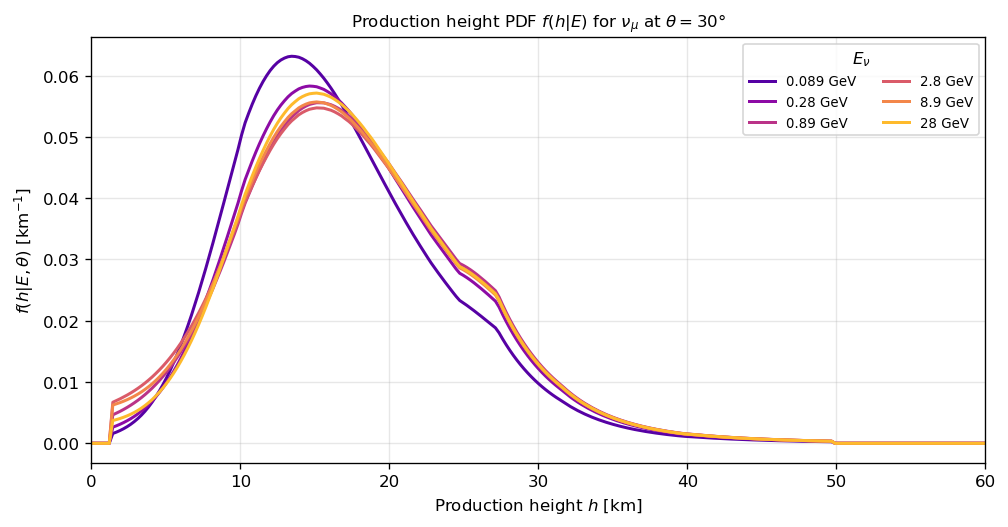

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig33_fEh.png


In [8]:
E_show  = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]   # GeV
colors  = plt.cm.plasma(np.linspace(0.15, 0.85, len(E_show)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for e_tgt, col in zip(E_show, colors):
    ie = np.argmin(np.abs(E_GeV - e_tgt))
    ax.plot(h_km, f_Eh[ie], color=col, lw=1.8, label=f'{E_GeV[ie]:.2g} GeV')

ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel(r'$f(h|E,\theta)$ [km$^{-1}$]')
ax.set_title(rf'Production height PDF $f(h|E)$ for $\nu_\mu$ at $\theta={THETA_DEG:.0f}°$', fontsize=10)
ax.set_xlim(0, 60)
ax.legend(title=r'$E_\nu$', ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show('atm4_fig33_fEh.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 3.4 Height-Differential Flux $\Phi(E, h)$

The height-differential source flux $\Phi(E,h) = \Phi(E;\theta) \times f(h|E,\theta)$
as a 2-D heatmap. This is the quantity passed to the neutrino transport equation as
the upper boundary condition.

**Expected results:**
- A 2-D field concentrated between 10–30 km at low energies, shifting
  toward lower altitudes with energy, with overall magnitude following the steeply
  falling MCEq energy spectrum.

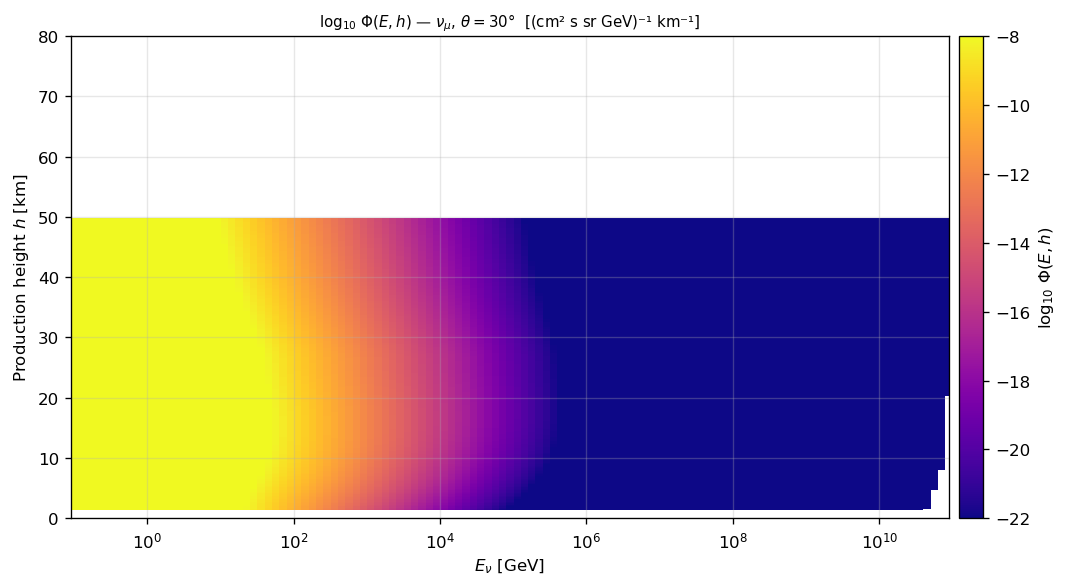

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig34_phi_Eh.png


In [9]:
with np.errstate(divide='ignore'):
    log_phi = np.where(phi_Eh > 0, np.log10(phi_Eh), np.nan)

E_mesh = np.concatenate([[E_GeV[0]*0.9], 0.5*(E_GeV[:-1]+E_GeV[1:]), [E_GeV[-1]*1.1]])
h_mesh = np.concatenate([[0.0], 0.5*(h_km[:-1]+h_km[1:]), [h_km[-1]+(h_km[-1]-h_km[-2])]])

fig, ax = plt.subplots(figsize=(9.5, 5.0))
im = ax.pcolormesh(E_mesh, h_mesh, log_phi.T, cmap='plasma',
                   shading='flat', vmin=-22, vmax=-8)
ax.set_xscale('log')
ax.set_xlim(E_GeV[0], E_GeV[-1])
ax.set_ylim(0, 80)
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel('Production height $h$ [km]')
ax.set_title(
    rf'$\log_{{10}}\,\Phi(E,h)$ — $\nu_\mu$, $\theta={THETA_DEG:.0f}°$'
    r'  [(cm² s sr GeV)⁻¹ km⁻¹]',
    fontsize=9,
)
plt.colorbar(im, ax=ax, label=r'$\log_{{10}}\,\Phi(E,h)$', pad=0.01)
fig.tight_layout()
save_and_show('atm4_fig34_phi_Eh.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 4. Angular Dependence

The MCEq cascade solve is inherently single-angle: a separate cascade ODE is solved
for each requested $\theta$. The flux varies substantially with zenith angle because:
- **Vertical** ($\theta \approx 0°$): short atmospheric path, highest production heights,
  lower multi-GeV flux.
- **Horizontal** ($\theta \approx 85°$): long path length, broad height distribution,
  enhanced multi-GeV flux from extended pion decay.

### 4.1 Generate Multi-Angle Grid

`generate_flux_for_particles_angle_grid()` dispatches one cascade solve per
(particle, angle) pair. A compact 5-angle grid is used here to keep runtime manageable.

In [10]:
THETA_GRID = np.array([0., 15., 30., 60., 80.])   # degrees
PARTICLES  = ["numu", "nue", "antinumu", "antinue"]

print(f'Generating MCEq flux for {len(PARTICLES)} particles x {len(THETA_GRID)} angles ...')

grid = generate_flux_for_particles_angle_grid(
    particles        = PARTICLES,
    theta_grid_deg   = THETA_GRID,
    model_config     = model_config,
    grid_config      = grid_config,
    smoothing_config = smoothing_config,
    parallel_config  = ParallelConfig(parallel=False),
    save             = False,
    device           = 'cpu',
    dtype            = torch.float64,
    debug            = True,
)

print(f'Generated flux for {len(PARTICLES)} particles x {len(THETA_GRID)} angles.')
for flav, gdata in grid.items():
    theta_keys = sorted(gdata['results'].keys())
    print(f'  {flav:10s}: theta = {[f"{t:.0f}" for t in theta_keys]}')

Generating MCEq flux for 4 particles x 5 angles ...
Generating 20 mceq flux jobs (4 particles x 5 angles). parallel=False


mceq flux generation:   0%|                                                                     | 0/20 [00:00<?, ?it/s]

Generating numu | alpha=None deg | theta=0.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


mceq flux generation:   5%|███                                                          | 1/20 [00:48<15:12, 48.02s/it]

Generating numu | alpha=None deg | theta=15.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


...

Generating antinue | alpha=None deg | theta=60.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


mceq flux generation:  95%|█████████████████████████████████████████████████████████   | 19/20 [13:08<00:10, 10.73s/it]

Generating antinue | alpha=None deg | theta=80.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)


mceq flux generation: 100%|████████████████████████████████████████████████████████████| 20/20 [13:24<00:00, 40.23s/it]

Generated flux for 4 particles x 5 angles.
  numu      : theta = ['0', '15', '30', '60', '80']
  nue       : theta = ['0', '15', '30', '60', '80']
  antinumu  : theta = ['0', '15', '30', '60', '80']
  antinue   : theta = ['0', '15', '30', '60', '80']


### 4.2 Angular Profile of $\Phi(E; \theta)$

The height-integrated $\nu_\mu$ flux as a function of energy for several zenith
angles, and the angular profile at a fixed reference energy.

**Expected results:**
- The horizontal direction ($\theta = 80°$) is enhanced by a factor $\sim 2\text{–3}$
  relative to the vertical ($\theta = 0°$) at energies above $\sim 1$ GeV.

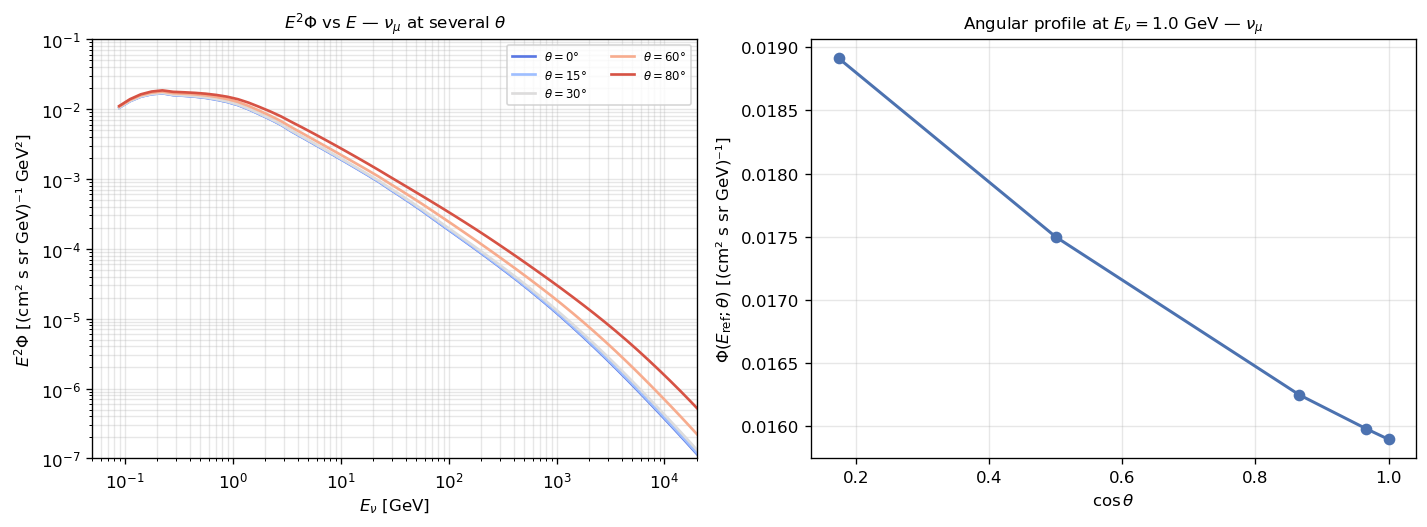

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig42_angular.png


In [11]:
E_ref    = 1.0   # GeV reference energy for the angular plot
colors_t = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(THETA_GRID)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: energy spectra at different theta
ax = axes[0]
for theta, col in zip(THETA_GRID, colors_t):
    r   = grid['numu']['results'][float(theta)]
    E   = r['E_grid_GeV'].cpu().numpy()
    phi = r['phi_E_obs'].cpu().numpy()
    ax.loglog(E, phi * E**2, color=col, lw=1.6, label=rf'$\theta={theta:.0f}°$')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$E^2 \Phi$ [(cm² s sr GeV)⁻¹ GeV²]')
ax.set_title(r'$E^2\Phi$ vs $E$ — $\nu_\mu$ at several $\theta$', fontsize=10)
ax.set_ylim(1e-7,1e-1)
ax.set_xlim(0.5*1e-1,2e4)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which='both', alpha=0.3)

# Right: angular profile at E_ref
ax = axes[1]
phi_at_E = []
for theta in THETA_GRID:
    r    = grid['numu']['results'][float(theta)]
    E    = r['E_grid_GeV'].cpu().numpy()
    phi  = r['phi_E_obs'].cpu().numpy()
    ie   = np.argmin(np.abs(E - E_ref))
    phi_at_E.append(phi[ie])

cosz_grid = np.cos(np.deg2rad(THETA_GRID))
ax.plot(cosz_grid, phi_at_E, 'o-', color='#4c72b0', lw=1.8, ms=6)
ax.set_xlabel(r'$\cos\theta$')
ax.set_ylabel(r'$\Phi(E_{\rm ref}; \theta)$ [(cm² s sr GeV)⁻¹]')
ax.set_title(rf'Angular profile at $E_\nu = {E_ref}$ GeV — $\nu_\mu$', fontsize=10)
ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show('atm4_fig42_angular.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 5. Production Height Statistics

Summarising $f(h|E,\theta)$ through its median and interquartile range gives compact
information about how the production-height distribution shifts with energy and angle.

### 5.1 Median Production Height vs Energy

The median height $\tilde h(E, \theta)$ is where the CDF of $f(h|E,\theta)$
equals 0.5. A higher median means neutrinos are produced higher in the atmosphere
(lower density, fewer hadronic interactions, more pion decays).

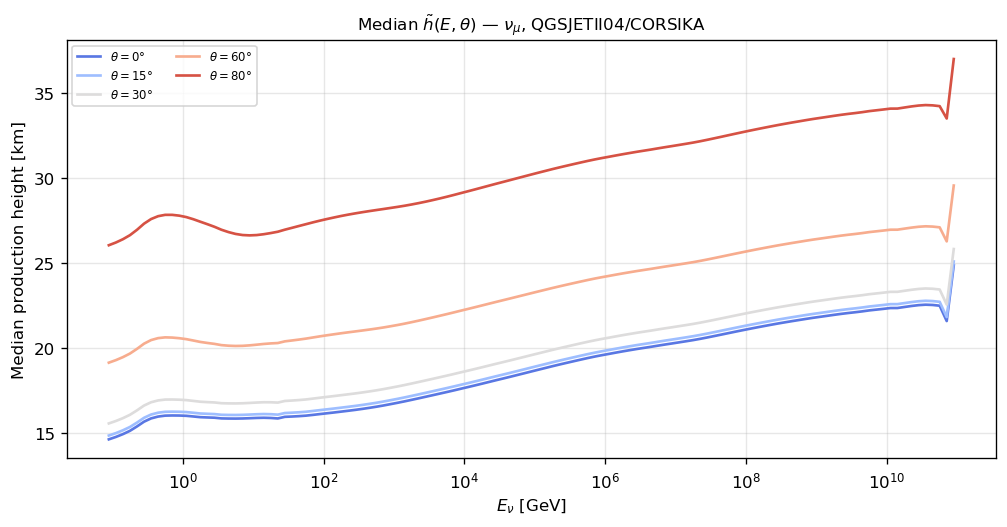

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig51_median_h.png


In [12]:
def median_height(f_Eh_arr, h_km_arr):
    cdf   = np.cumsum(f_Eh_arr * np.gradient(h_km_arr), axis=1)
    cdf  /= cdf[:, -1:].clip(1e-30)
    h_med = np.array([np.interp(0.5, cdf[ie], h_km_arr) for ie in range(cdf.shape[0])])
    return h_med

colors_t = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(THETA_GRID)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for theta, col in zip(THETA_GRID, colors_t):
    r     = grid['numu']['results'][float(theta)]
    E     = r['E_grid_GeV'].cpu().numpy()
    f     = r['f_Eh'].cpu().numpy()
    h     = r['h_grid_km'].cpu().numpy()
    h_med = median_height(f, h)
    ax.semilogx(E, h_med, color=col, lw=1.6, label=rf'$\theta={theta:.0f}°$')

ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel('Median production height [km]')
ax.set_title(rf'Median $\tilde h(E,\theta)$ — $\nu_\mu$, {INTERACTION_MODEL}/{DENSITY_MODEL}', fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
save_and_show('atm4_fig51_median_h.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 5.2 Height PDF Heatmap vs Zenith Angle

A 2-D heatmap of $f(h|E_0, \theta)$ as a function of $\theta$ and $h$ at a fixed
reference energy $E_0$ reveals how the production-height distribution broadens
toward horizontal directions.

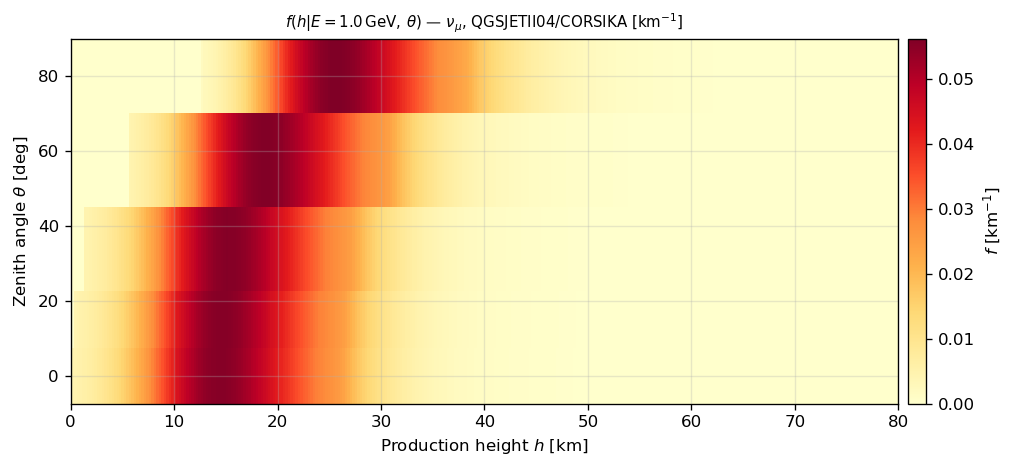

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig52_fEh_theta.png


In [13]:
E0 = 1.0   # GeV

f_theta_h = []
for theta in THETA_GRID:
    r  = grid['numu']['results'][float(theta)]
    E  = r['E_grid_GeV'].cpu().numpy()
    f  = r['f_Eh'].cpu().numpy()
    h  = r['h_grid_km'].cpu().numpy()
    ie = np.argmin(np.abs(E - E0))
    f_theta_h.append(f[ie])

F = np.array(f_theta_h)   # (n_theta, n_h)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.pcolormesh(h, THETA_GRID, F, cmap='YlOrRd', shading='auto')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel(r'Zenith angle $\theta$ [deg]')
ax.set_title(
    rf'$f(h|E={E0}\,{{\rm GeV}},\,\theta)$ — $\nu_\mu$, {INTERACTION_MODEL}/{DENSITY_MODEL}'
    r' [km$^{{-1}}$]',
    fontsize=9,
)
ax.set_xlim(0, 80)
plt.colorbar(im, ax=ax, label=r'$f$ [km$^{-1}$]', pad=0.01)
fig.tight_layout()
save_and_show('atm4_fig52_fEh_theta.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 6. Particle and Flavour Comparison

At energies below a few GeV, the atmospheric neutrino flux is dominated by $\nu_\mu$
and $\bar\nu_\mu$ from charged pion and muon decays. The $\nu_e$ receives an extra
contribution from 3-body kaon decays. Above a few GeV the ratio $\nu_\mu/\nu_e \to 2$
as muons from pion decays decay before reaching the ground. MCEq predicts all four
flavours self-consistently from a single cascade solve.

### 6.1 $\nu_e$ vs $\nu_\mu$ Spectra

**Expected results:**
- $\Phi(\nu_\mu)$ exceeds $\Phi(\nu_e)$ by a factor $\sim 2$ above 1 GeV.
- Below $\sim 0.3$ GeV the ratio $\Phi(\nu_\mu)/\Phi(\nu_e)$ drops toward 1
  because muons stop before decaying.

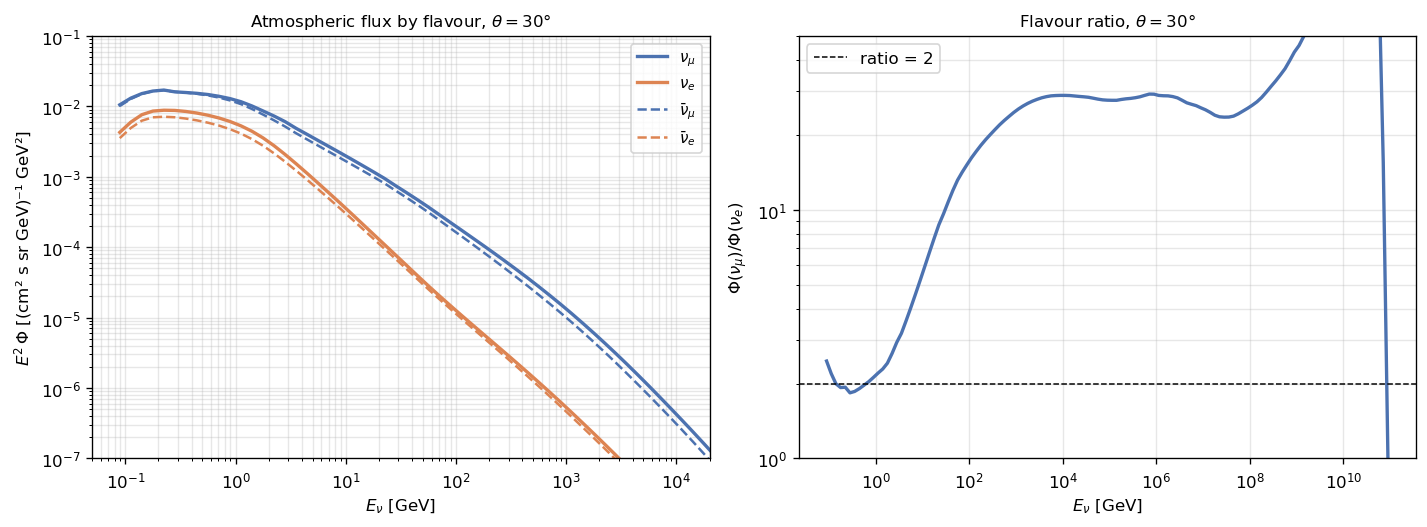

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig61_flavour.png


In [14]:
THETA0 = 30.0   # degrees
styles = {
    'numu':    dict(color='#4c72b0', lw=2.0, label=r'$\nu_\mu$'),
    'nue':     dict(color='#dd8452', lw=2.0, label=r'$\nu_e$'),
    'antinumu':dict(color='#4c72b0', lw=1.5, ls='--', label=r'$\bar\nu_\mu$'),
    'antinue': dict(color='#dd8452', lw=1.5, ls='--', label=r'$\bar\nu_e$'),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: all four flavours
ax = axes[0]
for flav, style in styles.items():
    r   = grid[flav]['results'][THETA0]
    E   = r['E_grid_GeV'].cpu().numpy()
    phi = r['phi_E_obs'].cpu().numpy()
    ax.loglog(E, phi * E**2, **style)
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$E^2\,\Phi$ [(cm² s sr GeV)⁻¹ GeV²]')
ax.set_title(rf'Atmospheric flux by flavour, $\theta={THETA0:.0f}°$', fontsize=10)
ax.set_ylim(1e-7,1e-1)
ax.set_xlim(0.5*1e-1,2e4)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# Right: nu_mu / nu_e ratio
ax = axes[1]
r_mu  = grid['numu']['results'][THETA0]
r_e   = grid['nue']['results'][THETA0]
E_mu  = r_mu['E_grid_GeV'].cpu().numpy()
phi_mu = r_mu['phi_E_obs'].cpu().numpy()
phi_e  = np.interp(E_mu, r_e['E_grid_GeV'].cpu().numpy(), r_e['phi_E_obs'].cpu().numpy())
ratio  = np.where(phi_e > 0, phi_mu / phi_e, np.nan)
ax.loglog(E_mu, ratio, color='#4c72b0', lw=2)
ax.axhline(2.0, color='k', lw=0.9, ls='--', label='ratio = 2')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$\Phi(\nu_\mu) / \Phi(\nu_e)$')
ax.set_title(rf'Flavour ratio, $\theta={THETA0:.0f}°$', fontsize=10)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(1e-0, 0.5*1e2)
fig.tight_layout()
save_and_show('atm4_fig61_flavour.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.2 $\nu / \bar\nu$ Ratios

The ratio $\Phi(\nu_\mu)/\Phi(\bar\nu_\mu)$ is driven by the excess of positive over
negative pions in proton-dominated cosmic-ray showers. Above a few GeV it stabilises
around $\sim 1.1\text{–1.3}$.

**Expected results:**
- $\nu/\bar\nu > 1$ for both flavours; weakly energy-dependent above 1 GeV.

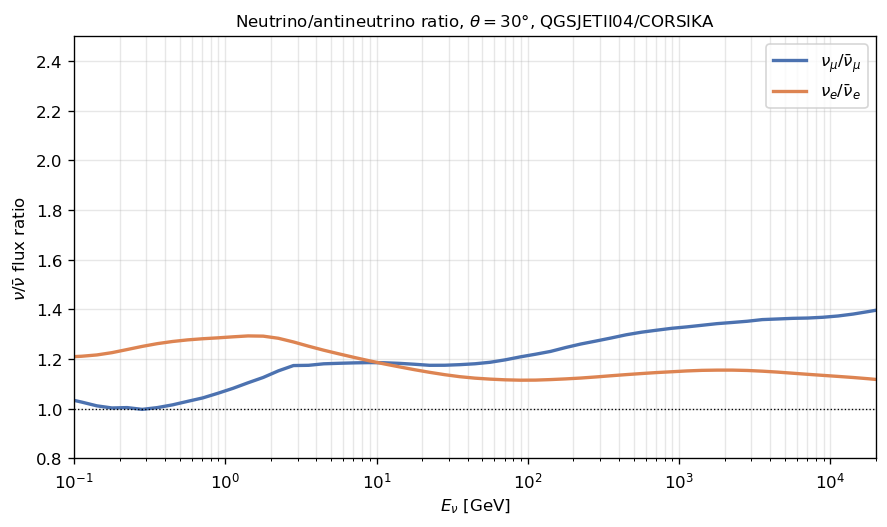

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig62_nu_ratio.png


In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for (flav, aflav, label, col) in [
    ('numu',  'antinumu', r'$\nu_\mu / \bar\nu_\mu$', '#4c72b0'),
    ('nue',   'antinue',  r'$\nu_e / \bar\nu_e$',     '#dd8452'),
]:
    r_nu   = grid[flav]['results'][THETA0]
    r_anu  = grid[aflav]['results'][THETA0]
    E      = r_nu['E_grid_GeV'].cpu().numpy()
    phi_nu = r_nu['phi_E_obs'].cpu().numpy()
    phi_an = np.interp(E, r_anu['E_grid_GeV'].cpu().numpy(), r_anu['phi_E_obs'].cpu().numpy())
    ratio  = np.where(phi_an > 0, phi_nu / phi_an, np.nan)
    ax.semilogx(E, ratio, color=col, lw=2, label=label)

ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$\nu / \bar\nu$ flux ratio')
ax.set_title(rf'Neutrino/antineutrino ratio, $\theta={THETA0:.0f}°$, {INTERACTION_MODEL}/{DENSITY_MODEL}', fontsize=10)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(1e-1, 2*1e4)
ax.set_ylim(0.8, 2.5)
fig.tight_layout()
save_and_show('atm4_fig62_nu_ratio.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 7. Physical Model Comparison

A key advantage of MCEq over Honda tables is the ability to change the physics models
explicitly and quantify the systematic uncertainty they introduce. This section
compares the $\nu_\mu$ flux under different interaction and density models.

### 7.1 Interaction Model Comparison

Different hadronic interaction models predict different $\pi/K$ production yields,
leading to differences in the predicted neutrino flux. The ratio
$\Phi_\text{SIBYLL23D} / \Phi_\text{QGSJETII04}$ quantifies this systematic.

**Expected results:**
- Differences of $\sim 5\text{–15\%}$ across the energy range, reflecting
  the hadronic model uncertainty in the neutrino flux prediction.

Running MCEq with SIBYLL23D for comparison ...
Generating numu | alpha=None deg | theta=30.000 deg
MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, 0)).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, 0)).
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('USStd', None)
5717.488834076821


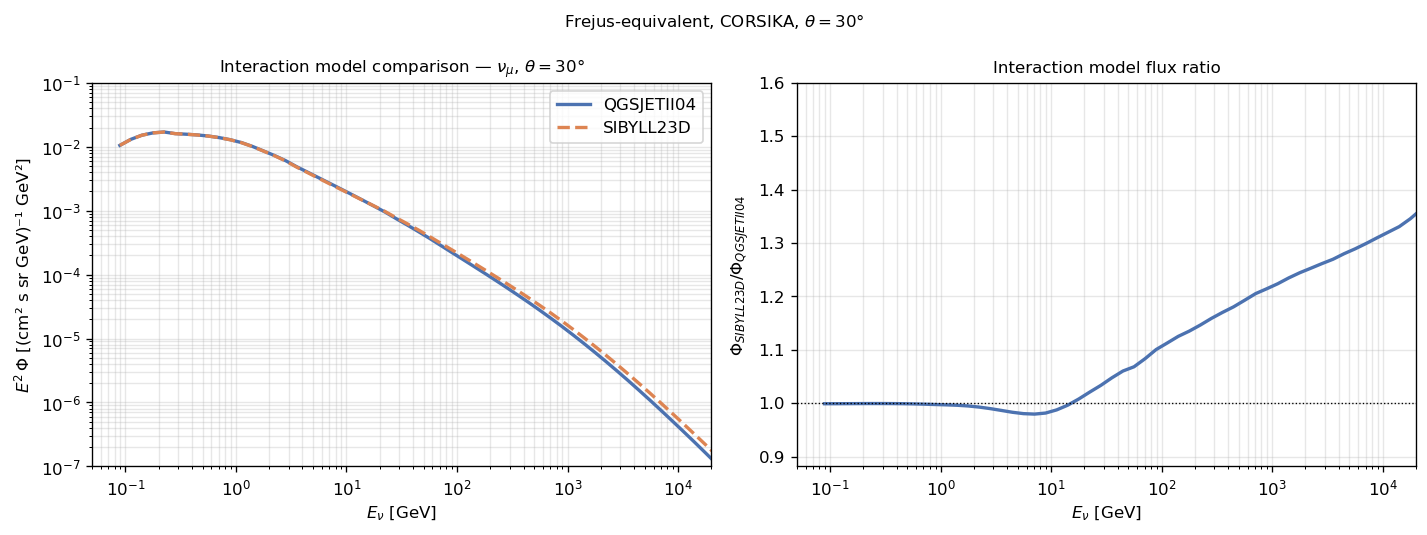

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig71_interaction_model.png


In [16]:
# Rerun single-angle generation with a second interaction model
INTERACTION_MODEL_2 = "SIBYLL23D"

model_config_2 = MCEqModelConfig(
    interaction_model = INTERACTION_MODEL_2,
    primary_model     = PRIMARY_MODEL,
    density_model     = DENSITY_MODEL,
    info              = False,
)

print(f'Running MCEq with {INTERACTION_MODEL_2} for comparison ...')
result_2 = generate_flux_for_particle_angle(
    'numu',
    theta_deg        = THETA_DEG,
    model_config     = model_config_2,
    grid_config      = grid_config,
    smoothing_config = smoothing_config,
    save             = False,
    device           = 'cpu',
    dtype            = torch.float64,
    debug            = True,
)
phi_E_2 = result_2['phi_E_obs'].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(E_GeV, phi_E * E_GeV**2, color='#4c72b0', lw=2, label=INTERACTION_MODEL)
ax.loglog(E_GeV, phi_E_2 * E_GeV**2, color='#dd8452', lw=2, ls='--', label=INTERACTION_MODEL_2)
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$E^2\,\Phi$ [(cm² s sr GeV)⁻¹ GeV²]')
ax.set_title(rf'Interaction model comparison — $\nu_\mu$, $\theta={THETA_DEG:.0f}°$', fontsize=10)
ax.set_xlim(0.5*1e-1, 2*1e4)
ax.set_ylim(1e-7, 1e-1)

ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ratio_int = np.where(phi_E > 0, phi_E_2 / phi_E, np.nan)
ax.semilogx(E_GeV, ratio_int, color='#4c72b0', lw=2)
ax.axhline(1.0, color='k', lw=0.8, ls=':')
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(rf'$\Phi_{{{INTERACTION_MODEL_2}}} / \Phi_{{{INTERACTION_MODEL}}}$')
ax.set_title('Interaction model flux ratio', fontsize=10)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim(0.5*1e-1, 2*1e4)
print(np.max(ratio_int))
ax.set_ylim(0.9*np.min(ratio_int), 1.6)
fig.suptitle(rf'Frejus-equivalent, {DENSITY_MODEL}, $\theta={THETA_DEG:.0f}°$', fontsize=10)
fig.tight_layout()
save_and_show('atm4_fig71_interaction_model.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 7.2 Density Model Comparison

The atmospheric density profile $\rho(X)$ affects how slant depth $X$ maps to
altitude $h$, and therefore the shape of the production-height PDF. Comparing
`CORSIKA` (US Standard Atmosphere) with `ICECUBE` (South Pole, NRLMSISE-00)
quantifies the site-dependence of the height-differential flux.

**Expected results:**
- Differences primarily in $f(h|E,\theta)$ shape; smaller effect on the
  integrated flux $\Phi(E;\theta)$.

Running MCEq with density model ICECUBE ...
Generating numu | alpha=None deg | theta=30.000 deg
MCEqRun::set_interaction_model(): QGSJETII04
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MCEqRun::set_density_model(): Setting density profile to CORSIKA ('BK_USStd', None)
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)
MCEqRun::set_density_model(): Setting density profile to MSIS00_IC ('SouthPole', 'January')
MSIS00IceCubeCentered::set_theta(): latitude = -89.99 for zenith angle = 30.00


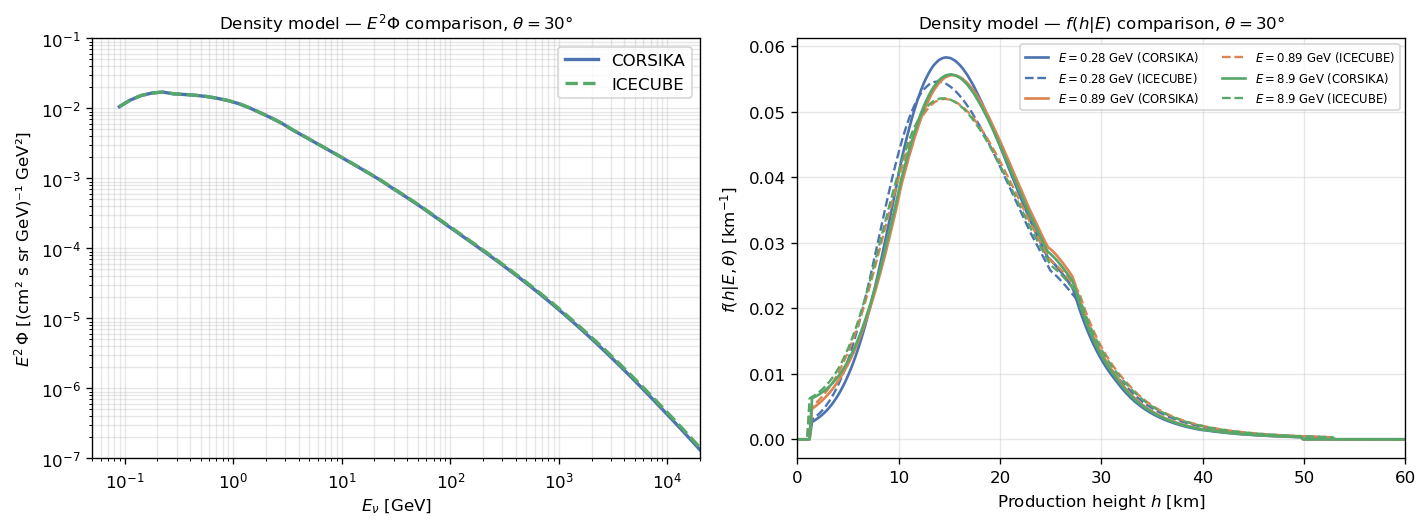

v:\output\analysis\atmosphere\mceq_analysis\atm4_fig72_density_model.png


In [17]:
# Rerun with a second density model
DENSITY_MODEL_2 = "ICECUBE"

model_config_3 = MCEqModelConfig(
    interaction_model = INTERACTION_MODEL,
    primary_model     = PRIMARY_MODEL,
    density_model     = DENSITY_MODEL_2,
    info              = False,
)

print(f'Running MCEq with density model {DENSITY_MODEL_2} ...')
result_3 = generate_flux_for_particle_angle(
    'numu',
    theta_deg        = THETA_DEG,
    model_config     = model_config_3,
    grid_config      = grid_config,
    smoothing_config = smoothing_config,
    save             = False,
    device           = 'cpu',
    dtype            = torch.float64,
    debug            = True,
)
phi_E_3   = result_3['phi_E_obs'].cpu().numpy()
f_Eh_3    = result_3['f_Eh'].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(E_GeV, phi_E * E_GeV**2,   color='#4c72b0', lw=2, label=DENSITY_MODEL)
ax.loglog(E_GeV, phi_E_3 * E_GeV**2, color='#55a868', lw=2, ls='--', label=DENSITY_MODEL_2)
ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'$E^2\,\Phi$ [(cm² s sr GeV)⁻¹ GeV²]')
ax.set_title(rf'Density model — $E^2\Phi$ comparison, $\theta={THETA_DEG:.0f}°$', fontsize=10)
ax.set_ylim(1e-7,1e-1)
ax.set_xlim(0.5*1e-1, 2*1e4)
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
E_show   = [0.3, 1.0, 10.0]
colors_e = ['#4c72b0', '#dd8452', '#55a868']
for e_tgt, col in zip(E_show, colors_e):
    ie = np.argmin(np.abs(E_GeV - e_tgt))
    ax.plot(h_km,   f_Eh[ie],   color=col, lw=1.6, ls='-',  label=rf'$E={E_GeV[ie]:.2g}$ GeV ({DENSITY_MODEL})')
    ax.plot(h_km, f_Eh_3[ie], color=col, lw=1.4, ls='--', label=rf'$E={E_GeV[ie]:.2g}$ GeV ({DENSITY_MODEL_2})')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel(r'$f(h|E,\theta)$ [km$^{-1}$]')
ax.set_title(rf'Density model — $f(h|E)$ comparison, $\theta={THETA_DEG:.0f}°$', fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.set_xlim(0, 60)
ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show('atm4_fig72_density_model.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 8. Flux Normalization Check

The height density $f(h|E,\theta)$ is normalised so that $\int_0^\infty f(h|E,\theta)\,dh = 1$
for each $(E, \theta)$ bin. Integrating the height-differential flux $\Phi(E,h)$ over $h$
must recover the original MCEq integrated flux $\Phi(E;\theta)$:

$$\Phi(E; X_{\rm obs}) = \int_0^{h_{\rm max}} \Phi(E,h)\,dh$$

This serves as a basic consistency check of the height-profile extraction pipeline.

### 8.1 Integrate $\Phi(E,h)$ over Height

**Expected results:**
- The reconstructed $\int \Phi(E,h)\,dh$ agrees with $\Phi(E; X_{\rm obs})$
  to better than $10^{-3}$ relative error for all energies and angles
  (limited by the smoothing step).

In [18]:
print(f"{'Particle':10s}  {'theta':>7s}  {'max|1 - integral|':>18s}  {'mean|1 - integral|':>20s}")
print('-' * 62)

for flav in ['numu', 'nue']:
    for theta in [0., 30., 60., 80.]:
        r     = grid[flav]['results'][theta]
        E     = r['E_grid_GeV'].cpu().numpy()
        h     = r['h_grid_km'].cpu().numpy()
        phi   = r['phi_E_obs'].cpu().numpy()
        f     = r['f_Eh'].cpu().numpy()
        phi_h = r['phi_Eh'].cpu().numpy()   # (nE, nh)

        # Check 1: normalization of f(h|E)
        norm_f = np.trapz(f, h, axis=1)   # should be 1 for all E

        # Check 2: integral of phi_Eh over h recovers phi_E
        phi_recov = np.trapz(phi_h, h, axis=1)
        with np.errstate(invalid='ignore', divide='ignore'):
            rel_err = np.where(phi > 0, np.abs(phi_recov / phi - 1.0), np.nan)

        print(f'{flav:10s}  {theta:6.0f}°  '
              f'{np.nanmax(rel_err):>18.2e}  {np.nanmean(rel_err):>20.2e}')

print()
print('Normalization of f(h|E) (should be 1):')
r0    = grid['numu']['results'][30.0]
f0    = r0['f_Eh'].cpu().numpy()
h0    = r0['h_grid_km'].cpu().numpy()
norms = np.trapz(f0, h0, axis=1)
print(f'  min = {norms.min():.6f}   max = {norms.max():.6f}   mean = {norms.mean():.6f}')

Particle      theta   max|1 - integral|    mean|1 - integral|
--------------------------------------------------------------
numu             0°            1.55e-15              3.97e-16
numu            30°            1.55e-15              3.75e-16
numu            60°            2.22e-15              4.28e-16
numu            80°            1.78e-15              4.24e-16
nue              0°            1.33e-15              4.29e-16
nue             30°            1.55e-15              4.23e-16
nue             60°            1.78e-15              4.08e-16
nue             80°            1.78e-15              4.48e-16

Normalization of f(h|E) (should be 1):
  min = 1.000000   max = 1.000000   mean = 1.000000


## 9. Summary

| Step | Function / class | Output |
|------|-----------------|--------|
| Select physics | `MCEqModelConfig(interaction_model, primary_model, density_model)` | Config dataclass |
| Set grids | `GridConfig(X_grid_gcm2, h_grid_km, X_obs_gcm2)` | Config dataclass |
| Set smoothing | `SmoothingConfig(method, smoothing, positive_only)` | Config dataclass |
| Single angle | `generate_flux_for_particle_angle(particle, theta_deg=..., model_config=..., grid_config=..., smoothing_config=..., save=False)` | `E_grid_GeV`, `X_grid_gcm2`, `h_grid_km`, `phi_E_obs`, `f_Eh`, `phi_Eh`, `flux_XE`, `flux_smooth_XE` |
| Full grid | `generate_flux_for_particles_angle_grid(particles, theta_grid_deg=..., model_config=..., ..., save=False)` | Dict keyed by flavour → Dict keyed by θ |

**Key physics findings (MCEq vs Honda):**
- The cascade solution $\Phi(E,X;\theta)$ is directly accessible — not available in Honda tables.
- Production height PDF $f(h|E,\theta)$ is derived analytically from $d\Phi/dX$;
  Honda uses quantile-based CDF reconstruction (atmosphere2 §0.5).
- The $\nu_\mu/\nu_e$ ratio approaches 2 above $\sim 1$ GeV, consistent with Honda.
- Interaction model uncertainty (QGSJETII04 vs SIBYLL23D): $\sim 5\text{–15\%}$.
- Density model (CORSIKA vs ICECUBE) mainly affects $f(h|E,\theta)$ shape,
  with smaller impact on $\Phi(E;\theta)$.
- Normalization check: $\int f(h|E)\,dh = 1$ to machine precision.

**Next step:** Use `generate_flux_for_particles_angle_grid(..., save=True, output_config=...)`
to write the height-differential flux files needed by the tpeanuts atmosphere propagation pipeline
(see atmosphere5_Differential_Flux_MCEq_Generation).

In [19]:
print('=' * 60)
print('Atmosphere Analysis 4 — Summary')
print('=' * 60)
print(f'  Interaction model : {INTERACTION_MODEL}')
print(f'  Primary model     : {PRIMARY_MODEL}')
print(f'  Density model     : {DENSITY_MODEL}')
print(f'  X grid            : {X_gcm2[0]:.1f} -- {X_gcm2[-1]:.0f} g/cm2 ({X_gcm2.size} pts)')
print(f'  Energy range      : {E_GeV[0]:.3g} -- {E_GeV[-1]:.3g} GeV ({E_GeV.size} pts)')
print(f'  Height range      : {h_km[0]:.0f} -- {h_km[-1]:.0f} km ({h_km.size} pts)')
print(f'  Particles shown   : {PARTICLES}')
print(f'  Theta grid        : {list(THETA_GRID)}')
print(f'  Output dir        : {OUTPUT_DIR}')

Atmosphere Analysis 4 — Summary
  Interaction model : QGSJETII04
  Primary model     : HillasGaisser H3a
  Density model     : CORSIKA
  X grid            : 1.0 -- 1030 g/cm2 (101 pts)
  Energy range      : 0.0891 -- 8.91e+10 GeV (121 pts)
  Height range      : 0 -- 120 km (501 pts)
  Particles shown   : ['numu', 'nue', 'antinumu', 'antinue']
  Theta grid        : [0.0, 15.0, 30.0, 60.0, 80.0]
  Output dir        : v:\output\analysis\atmosphere\mceq_analysis
